In [1]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,depths,reduce_list_half_preserve_extremes

from geometry import * 

eps = 1E-7
rcpsize = 14
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0


/home/acevedo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
modelA = 'deepseek'
# modelA = 'qwen7b'
# modelA = 'gemma12b'
modelB = modelA
languages = [
            'english',
            # 'italian',
            # 'spanish',
            # 'german',
            # 'chinese',
            ]

layers_A = list(range(1,depths[modelA] + 1))
layers_B = list(range(1,depths[modelB] + 1))
layers = np.array(reduce_list_half_preserve_extremes(layers_A),dtype=int)
relative_depths = layers.astype(float) / depths[modelB]

batch_shuffle = 0
centers_var = 'sem'
n_files = 21
avg_flags = [0,1]
Nbits = 0
match_var = 'matching'
data_var = 'sem'
zero_activations_list = [0]
center_A_flags = [0,1,-1]

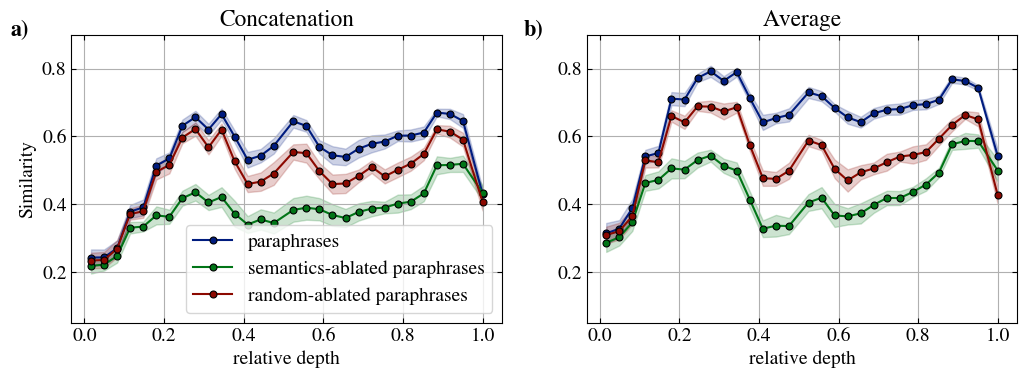

In [6]:
precision = 32
ratio_jackkniffe = 0.5
removal_method = 'projection'

fig,ax = plt.subplots(1,2,figsize=(10.5,4))
token_offset = 0
for avg_id,avg_tokens in enumerate(avg_flags):
    title = ' '
    plot_id = 0
    min_token_length = 3
    n_tokens = min_token_length
    for zero_id,zero_activations in enumerate(zero_activations_list):
      for center_A_id,center_A_flag in enumerate(center_A_flags):
          number_of_languages = 6 if center_A_flag != 0 else None
          center_B_flag = center_A_flag
          output_folder0 = makefolder(base=f'./results/',
                                      global_centering=0,
                                      spaces='AB',
                                      similarity_fn='normalized_L2_distance',
                                      precision=precision,
                                      language='english',
                                      data_var=data_var,
                                      modelA=modelA,
                                      modelB=modelB,
                                      match_var=match_var,
                                      n_files=n_files,
                                      min_token_length=min_token_length,
                                      )
          II_folder = makefolder(base=output_folder0,
                                            centers=centers_var,
                                            Nbits=Nbits,
                                            n_tokens=n_tokens,
                                            avg_tokens=avg_tokens,
                                            batch_shuffle=batch_shuffle,
                                            zero_activations=zero_activations,
                                            center_A_flag=center_A_flag,
                                            center_B_flag=center_B_flag,
                                            number_of_languages=number_of_languages,
                                            language_list_permutation=0 if number_of_languages is not None else None,
                                            removal_method=removal_method if center_A_flag != 0 else None,
                                            )
          inf_imb = 1 - np.load(II_folder + f"II_{ratio_jackkniffe:.2f}.npy").mean(axis=0)
          std = np.load(II_folder + f"II_jack_std_{ratio_jackkniffe:.2f}.npy").mean(axis=0)
          
          color = colors[plot_id] 
          linestyle = '-'
          if avg_tokens:
            title = f'Average'
          else:
            title = f'Concatenation'

          label = ''
          if center_A_flag == 0:
            # label += r'$\mathbf{X}_i \rightarrow \mathbf{P}_i$'
            label += 'paraphrases'
          if center_A_flag == -1:
            # label += r'$\mathbf{X}_i \perp \mathbf{T}_r \rightarrow \mathbf{P}_i \perp \mathbf{T}_r$'
              label = 'random-ablated paraphrases'
          if center_A_flag == 1:
            # label += r'$\mathbf{X}_i \perp \mathbf{T}_i \rightarrow \mathbf{P}_i \perp \mathbf{T}_i $'
              label = 'semantics-ablated paraphrases'

          ax[avg_id].plot(
              relative_depths,
              inf_imb.diagonal(),
              label=label,
              color=color,
              marker='o',                # circular marker
              markersize=5,              # tweakable size
              markerfacecolor=color,     # fill same as line
              markeredgecolor='black',   # cute black border
              markeredgewidth=0.8,       # adjust border thickness
          )

          ax[avg_id].fill_between(relative_depths,
                          inf_imb.diagonal() - std.diagonal(),
                          inf_imb.diagonal() + std.diagonal(),
                          alpha=0.2,
                          color=color,
                          )
          plot_id += 1

    ax[avg_id].set_xlabel('relative depth')
    if avg_id == 0:
      ax[avg_id].set_ylabel('Similarity')

    ax[avg_id].grid()
    ax[avg_id].tick_params(
        top=True, bottom=True, left=True, right=True,  # enable ticks
        labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
        direction='in'  # ticks point inward
        )
    ax[avg_id].set_ylim(0.05,.9)

    ax[avg_id].set_title(title)

# Inner legends in both subplots
for a in ax[:1]:
    handles, labels = [], []
    for line in a.get_lines():
        label = line.get_label()
        if label:
            handles.append(line)
            labels.append(label)
    a.legend(handles, labels, loc='best', fontsize=rcpsize, framealpha=0.8)


# Add panel labels
panel_labels = ['a)', 'b)']
for i, label in enumerate(panel_labels):
    ax[i].text(
        -0.1, 1.05,      # x, y in axis coordinates
        label,
        transform=ax[i].transAxes,  # coordinates relative to the axes
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='right'
    )
# if modelA != 'deepseek':
#   fig.suptitle(f'{modelA.capitalize()}')
figs_folder = 'results/figs/semantic_similarity'
os.makedirs(figs_folder, exist_ok=True)
fig.savefig(f'{figs_folder}/semantic_similarity_{modelA}_{removal_method}_{center_A_flags}.pdf', bbox_inches='tight')
plt.show()

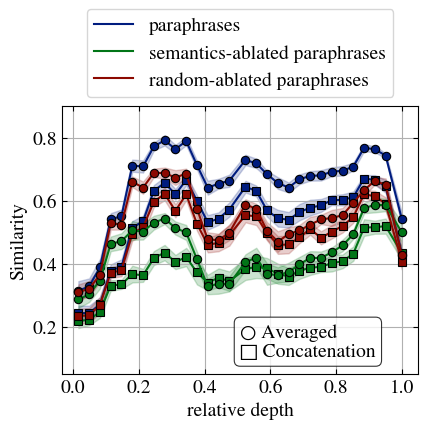

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

precision = 32
ratio_jackkniffe = 0.5

# Single panel (merged)
fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5))

min_token_length = 3
n_tokens = min_token_length

for avg_id, avg_tokens in enumerate(avg_flags):

    plot_id = 0

    for zero_id, zero_activations in enumerate(zero_activations_list):
        for center_A_id, center_A_flag in enumerate(center_A_flags):

            number_of_languages = 6 if center_A_flag != 0 else None
            center_B_flag = center_A_flag

            # Match your original logic: removal_method used only when center_A_flag != 0
            removal_method = 'projection' if center_A_flag != 0 else None

            output_folder0 = makefolder(
                base=f'./results/',
                global_centering=0,
                spaces='AB',
                similarity_fn='normalized_L2_distance',
                precision=precision,
                language='english',
                data_var=data_var,
                modelA=modelA,
                modelB=modelB,
                match_var=match_var,
                n_files=n_files,
                min_token_length=min_token_length,
            )

            II_folder = makefolder(
                base=output_folder0,
                centers=centers_var,
                Nbits=Nbits,
                n_tokens=n_tokens,
                avg_tokens=avg_tokens,
                batch_shuffle=batch_shuffle,
                zero_activations=zero_activations,
                center_A_flag=center_A_flag,
                center_B_flag=center_B_flag,
                number_of_languages=number_of_languages,
                language_list_permutation=0 if number_of_languages is not None else None,
                removal_method=removal_method,
            )

            inf_imb = 1 - np.load(II_folder + f"II_{ratio_jackkniffe:.2f}.npy").mean(axis=0)
            std     =     np.load(II_folder + f"II_jack_std_{ratio_jackkniffe:.2f}.npy").mean(axis=0)

            color = colors[plot_id]

            # Marker shape encodes avg vs concat
            if avg_tokens:
                marker = 'o'
                linestyle = '-'
            else:
                marker = 's'
                linestyle = '-'

            # Labels (same text as your original)
            label = ''
            if center_A_flag == 0:
                label = 'paraphrases'
            if center_A_flag == -1:
                label = 'random-ablated paraphrases'
            if center_A_flag == 1:
                label = 'semantics-ablated paraphrases'

            _label = label if label else None

            # 1) LINES ONLY with labels (for the legend)
            ax.plot(
                relative_depths,
                inf_imb.diagonal(),
                label=_label,
                color=color,
                linestyle=linestyle,
                linewidth=1.5,
            )

            # 2) MARKERS ONLY (no labels)
            ax.plot(
                relative_depths,
                inf_imb.diagonal(),
                linestyle='None',
                marker=marker,
                markersize=6,
                markerfacecolor=color,
                markeredgecolor='black',
                markeredgewidth=0.8,
            )

            # Error band
            ax.fill_between(
                relative_depths,
                inf_imb.diagonal() - std.diagonal(),
                inf_imb.diagonal() + std.diagonal(),
                alpha=0.2,
                color=color,
            )

            plot_id += 1

# Axes formatting
ax.set_ylabel('Similarity')
ax.set_xlabel('relative depth')
ax.grid()

ax.tick_params(
    top=True, bottom=True, left=True, right=True,
    labeltop=False, labelbottom=True, labelleft=True, labelright=False,
    direction='in'
)

ax.set_ylim(0.05, 0.9)

# --- Legend ABOVE (deduplicate labels) ---
handles, labels = ax.get_legend_handles_labels()
by_label = {}
for h, lab in zip(handles, labels):
    if lab and lab not in by_label:
        by_label[lab] = h

# Leave room for legend above
fig.subplots_adjust(top=0.72)

ax.legend(
    by_label.values(),
    by_label.keys(),
    loc='upper center',
    bbox_to_anchor=(0.5, 1.4),
    ncol=min(1, len(by_label)),
    framealpha=0.8,
    fontsize=rcpsize,
)

# --- Marker-shape textbox (avg vs concat) ---
marker_box_text = "○ Averaged\n□ Concatenation"
ax.text(
    0.5, 0.05,
    marker_box_text,
    transform=ax.transAxes,
    fontsize=rcpsize,
    verticalalignment='bottom',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        edgecolor='black',
        alpha=0.8,
        linewidth=0.8,
    ),
)

# Save
figs_folder = 'results/figs/semantic_similarity'
os.makedirs(figs_folder, exist_ok=True)
fig.savefig(
    f'{figs_folder}/semantic_similarity_{modelA}_merged_{center_A_flags}.pdf',
    bbox_inches='tight'
)

plt.show()


### Correlation coefficient 

FileNotFoundError: [Errno 2] No such file or directory: './results/global_centering_0/spaces_AB/similarity_fn_normalized_L2_distance/precision_32/language_english/data_var_sem/modelA_deepseek/modelB_deepseek/match_var_matching/n_files_21/min_token_length_3/centers_sem/Nbits_0/n_tokens_3/avg_tokens_0/batch_shuffle_0/zero_activations_0/center_A_flag_1/center_B_flag_1/number_of_languages_6/language_list_permutation_0/corr_coeff_0.50.npy'

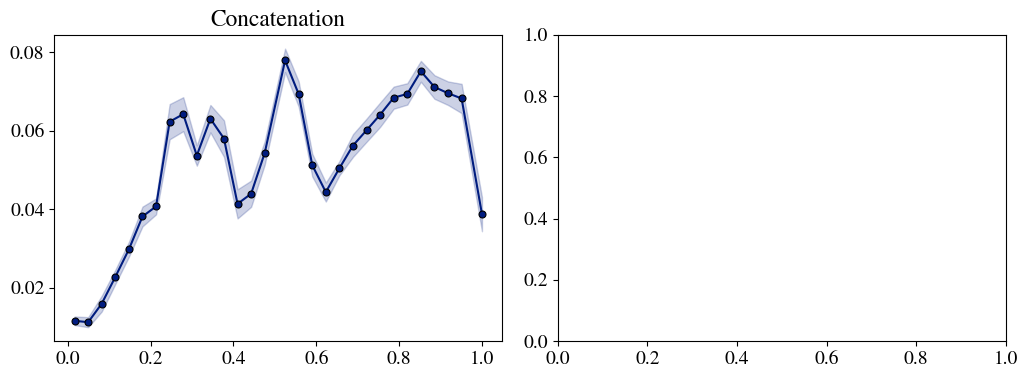

In [4]:
### mean and std of xis: 
precision = 32

fig,ax = plt.subplots(1,2,figsize=(10.5,4))
for avg_id,avg_tokens in enumerate(avg_flags):
  title = ' '
  plot_id = 0
  if avg_tokens:
    min_token_length = -1
  else:
    min_token_length = 3
  n_tokens = min_token_length
  for zero_id,zero_activations in enumerate(zero_activations_list):
    for center_A_id,center_A_flag in enumerate(center_A_flags):
        removal_method = removal_method if center_A_flag != 0 else None
        center_B_flag = center_A_flag
        number_of_languages = 6 if center_A_flag != 0 else None
        output_folder0 = makefolder(base=f'./results/',
                                    global_centering=0,
                                    spaces='AB',
                                    similarity_fn='normalized_L2_distance',
                                    precision=precision,
                                    language='english',
                                    data_var=data_var,
                                    modelA=modelA,
                                    modelB=modelB,
                                    match_var=match_var,
                                    n_files=n_files,
                                    min_token_length=min_token_length,
                                    )
        II_folder = makefolder(base=output_folder0,
                                          centers=centers_var,
                                          Nbits=Nbits,
                                          n_tokens=n_tokens,
                                          avg_tokens=avg_tokens,
                                          batch_shuffle=batch_shuffle,
                                          zero_activations=zero_activations,
                                          center_A_flag=center_A_flag,
                                          center_B_flag=center_B_flag,
                                          number_of_languages=number_of_languages,
                                          language_list_permutation=0 if number_of_languages is not None else None,
                                          removal_method=removal_method,
                                          )
        
        corr_coeff_mu = np.load(II_folder + f"corr_coeff_{ratio_jackkniffe:.2f}.npy")
        corr_coeff_std = np.load(II_folder + f"corr_coeff_jack_std_{ratio_jackkniffe:.2f}.npy")
        
        color = colors[plot_id] 
        linestyle = '-'
        if avg_tokens:
          title = f'Average'
        else:
          title = f'Concatenation'
        ax[avg_id].set_title(title)

        label = ''
        if center_A_flag == 0:
          # label += r'$\mathbf{X}_i \rightarrow \mathbf{P}_i$'
          label += 'paraphrases'
        if center_A_flag == -1:
          # label += r'$\mathbf{X}_i \perp \mathbf{T}_r \rightarrow \mathbf{P}_i \perp \mathbf{T}_r$'
            label = 'random-ablated paraphrases'
        if center_A_flag == 1:
          # label += r'$\mathbf{X}_i \perp \mathbf{T}_i \rightarrow \mathbf{P}_i \perp \mathbf{T}_i $'
            label = 'semantics-ablated paraphrases'

        for II_index in range(1):
          ax[avg_id].plot(
              relative_depths,
              corr_coeff_mu[II_index].diagonal(),
              label=label,
              linestyle=_linestyles[II_index],
              color=color,
              marker='o',                # circular marker
              markersize=5,              # tweakable size
              markerfacecolor=color,     # fill same as line
              markeredgecolor='black',   # cute black border
              markeredgewidth=0.8,       # adjust border thickness
          )

          ax[avg_id].fill_between(relative_depths,
                          corr_coeff_mu[II_index].diagonal() - corr_coeff_std[II_index].diagonal(),
                          corr_coeff_mu[II_index].diagonal() + corr_coeff_std[II_index].diagonal(),
                          alpha=0.2,
                          color=color,
                          )
        plot_id += 1
  ax[avg_id].grid()
  ax[avg_id].set_xlabel('relative depth')
  if avg_id == 0:
    ax[avg_id].set_ylabel("Chatterjee's mean ξ")

# Inner legends in both subplots
for a in ax[:1]:
    handles, labels = [], []
    for line in a.get_lines():
        label = line.get_label()
        if label:
            handles.append(line)
            labels.append(label)
    a.legend(handles, labels, loc='best', fontsize=rcpsize, framealpha=0.8)



# Add panel labels
panel_labels = ['a)', 'b)']
for i, label in enumerate(panel_labels):
    ax[i].text(
        -0.1, 1.05,      # x, y in axis coordinates
        label,
        transform=ax[i].transAxes,  # coordinates relative to the axes
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='right'
    )

# After plotting everything, compute global min and max
all_mins, all_maxs = [], []

for avg_id in range(2):
    for line in ax[avg_id].get_lines():
        ydata = line.get_ydata()
        all_mins.append(-0.005)
        all_maxs.append(np.max(ydata)*1.2)

global_min = min(all_mins)
global_max = max(all_maxs)

# Optionally, add some margin
margin = 0.05 * (global_max - global_min)
global_min -= margin
global_max += margin

# Set same ylims for both subplots
for avg_id in range(2):
    ax[avg_id].set_ylim(global_min, global_max)


# os.makedirs('results/figs', exist_ok=True)
fig.savefig(f'{figs_folder}/corr_coeff_semantic_similarity_{modelA}_{removal_method}.pdf', bbox_inches='tight')
plt.show()